## Multi-Turn Chatbot — Message History in State


In [8]:
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
import operator


# --- 1. STATE ---
class State(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]
    # Because of operator.add, each new message is APPENDED
    # to history — never overwritten. This is the full conversation.

In [9]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage

from dotenv import load_dotenv

load_dotenv()


# --- 2. NODE ---
llm = ChatOpenAI(model="gpt-4o-mini")
SYSTEM = SystemMessage(content="You are a helpful assistant. You remember everything said in this conversation.")


def chatbot_node(state: State) -> dict:
    all_msgs = [SYSTEM] + state["messages"]
    response = llm.invoke(all_msgs)
    print(f"[chatbot] History length: {len(state['messages'])} msgs")
    return {"messages": [response]}  # appended via operator.add

In [10]:
from langgraph.graph import StateGraph, START, END

# --- 3. GRAPH ---
builder = StateGraph(State)
builder.add_node("chatbot", chatbot_node)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)
graph = builder.compile()

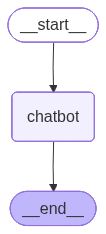

In [11]:
# --- 4. VISUALIZE ---
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
from langchain_core.messages import HumanMessage, BaseMessage

# --- 5. MULTI-TURN SIMULATION ---
print("=== Multi-Turn Chatbot ===\n")
history: list[BaseMessage] = []

turns = [
    "Hi! My name is Yash and I live in Bangalore.",
    "I'm building a LangGraph YouTube series.",
    "What's my name, where do I live, and what am I working on?",  # memory test
    "Summarise our entire conversation in 2 bullet points.",
]

# for user_text in turns:
while True:
    user_text = input().lower()
    if user_text == "exit" or user_text == "quit":
        break

    history.append(HumanMessage(content=user_text))
    result = graph.invoke({"messages": history})
    ai_msg = result["messages"][-1]
    history.append(ai_msg)  # keep AI reply in history for next turn

    print(f"👤 {user_text}")
    print(f"🤖 {ai_msg.content}\n")

=== Multi-Turn Chatbot ===

[chatbot] History length: 1 msgs
👤 hello my name is yash
🤖 Hello, Yash! How can I assist you today?

[chatbot] History length: 3 msgs
👤 what is my name
🤖 Your name is Yash. How can I help you today?

[chatbot] History length: 5 msgs
👤 i love to code and i am learning coding every day
🤖 That's great to hear, Yash! Coding is a valuable skill and it can be very rewarding. What programming languages are you learning, or is there a particular project you're working on?

[chatbot] History length: 7 msgs
👤 if i want to master the trees and graph and bfs and dfs and shortest path problems, what is the solid approach from basic to advanced
🤖 Mastering trees, graphs, and related algorithms like BFS, DFS, and shortest path problems can be a rewarding journey. Here's a structured approach to help you progress from basic to advanced levels:

### 1. **Understanding the Basics**
   - **Data Structures**: Familiarize yourself with basic data structures like arrays, linked l